### Naive Bayes Classifier

**Algorithm:** GaussianNB

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    cross_validate,
    learning_curve
)
from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB,
    ComplementNB
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
from pathlib import Path

data_url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/crop_recommendation/train_set_label.csv"
local_data_path = Path("../../data/train_set_label.csv")

try:
    df = pd.read_csv(data_url)
    print("Loaded dataset from URL")
except Exception as exc:
    if local_data_path.exists():
        df = pd.read_csv(local_data_path)
        print(f"Loaded dataset from local file: {local_data_path.resolve()}")
    else:
        raise RuntimeError(
            "Could not load dataset from URL (network/DNS issue) and local fallback file was not found. "
            f"Download the CSV and save it at: {local_data_path.resolve()}"
        ) from exc

print(df.head())

Loaded dataset from URL
       N      P      K  temperature   humidity        ph    rainfall      crop
0   17.0  136.0  196.0    23.871923  90.499390  5.882156  103.054809     apple
1   49.0   69.0   82.0    18.315615  15.361435  7.263119   81.787105  chickpea
2   74.0   49.0   38.0    23.314104  71.450905  7.488014  164.497037      jute
3  104.0   35.0   28.0    27.510061  50.666872  6.983732  143.995555    coffee
4   23.0   72.0   84.0    19.020613  17.131591  6.920251   79.926981  chickpea


In [4]:
# Feature columns
feature_col = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
# Separate features and target
X = df[feature_col]
y = df['crop']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")

  Training set: 1320 samples
  Test set: 330 samples


In [5]:
#feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Baseline Gaussian Naive Bayes Model

In [6]:

# Create baseline GaussianNB
nb_baseline = GaussianNB(
    var_smoothing=1e-09  # Default smoothing parameter
)

# Train the model
nb_baseline.fit(X_train_scaled, y_train)

# Predictions
y_pred_baseline = nb_baseline.predict(X_test_scaled)

# Evaluate
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline, average='weighted')
recall_baseline = recall_score(y_test, y_pred_baseline, average='weighted')
f1_baseline = f1_score(y_test, y_pred_baseline, average='weighted')

print(f"   Accuracy:  {accuracy_baseline:.4f} ({accuracy_baseline*100:.2f}%)")
print(f"   Precision: {precision_baseline:.4f}")
print(f"   Recall:    {recall_baseline:.4f}")
print(f"   F1-Score:  {f1_baseline:.4f}")


   Accuracy:  0.9909 (99.09%)
   Precision: 0.9924
   Recall:    0.9909
   F1-Score:  0.9908


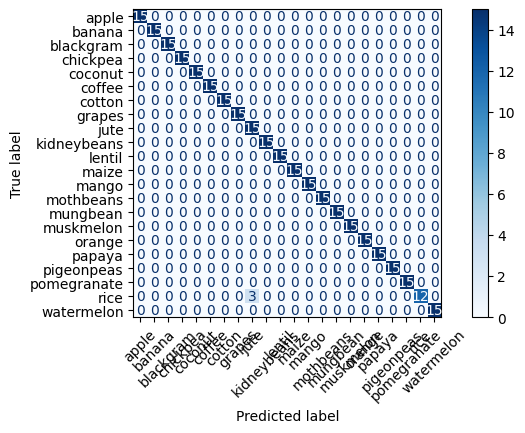

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4))
cm = confusion_matrix(y_test, y_pred_baseline)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp1.plot(ax=axes, cmap='Blues', xticks_rotation=45)




Confidence Statistics:
  Mean confidence: 0.9923
  Std confidence:  0.0446
  Min confidence:  0.5465
  Max confidence:  1.0000


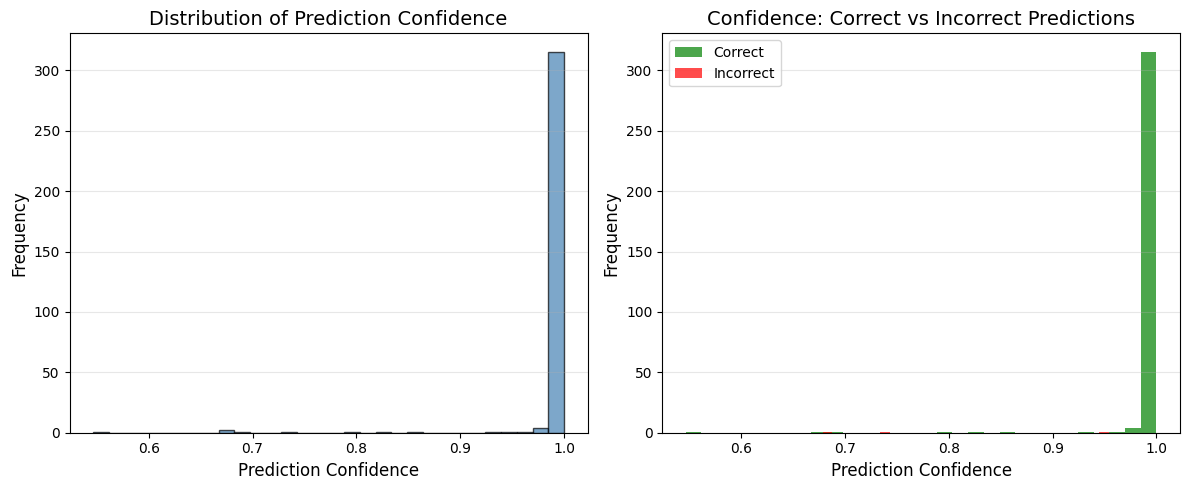

In [8]:
#probability analysis

# Get probability estimates for test set
y_proba = nb_baseline.predict_proba(X_test_scaled)

# Find predictions with highest confidence
max_proba = np.max(y_proba, axis=1)
predicted_classes = np.argmax(y_proba, axis=1)

print(f"\nConfidence Statistics:")
print(f"  Mean confidence: {np.mean(max_proba):.4f}")
print(f"  Std confidence:  {np.std(max_proba):.4f}")
print(f"  Min confidence:  {np.min(max_proba):.4f}")
print(f"  Max confidence:  {np.max(max_proba):.4f}")

# Visualize confidence distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(max_proba, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Prediction Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Confidence', fontsize=14)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
# Compare confidence for correct vs incorrect predictions
correct_mask = (predicted_classes == y_test)
plt.hist(max_proba[correct_mask], bins=30, alpha=0.7, label='Correct', color='green')
plt.hist(max_proba[~correct_mask], bins=30, alpha=0.7, label='Incorrect', color='red')
plt.xlabel('Prediction Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Confidence: Correct vs Incorrect Predictions', fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
import joblib
from pathlib import Path

model_obj = globals().get("best_model")
output_path = Path("../../models/naive_bayes.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_obj, output_path)
print(f"Saved model to: {output_path.resolve()}")

Saved model to: /media/kushagra/DATA/notebook/crop-recommendation-ml-system/models/naive_bayes.pkl


In [10]:
sample_input = [[17.0,  136.0,  196.0,    23.871923,  90.499390,  5.882156,  103.054809]]  # N, P, K, temperature, humidity, ph, rainfall
prediction = nb_baseline.predict(sample_input)
print(f"Predicted crop: {le.inverse_transform([prediction[0]])[0]}")

Predicted crop: jute


In [11]:
artifacts_dir = Path("../../models")
artifacts_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(le, artifacts_dir / "label_encoder.pkl")
joblib.dump(scaler, artifacts_dir / "scaler.pkl")

print("Saved:", (artifacts_dir / "label_encoder.pkl").resolve())
print("Saved:", (artifacts_dir / "scaler.pkl").resolve())

Saved: /media/kushagra/DATA/notebook/crop-recommendation-ml-system/models/label_encoder.pkl
Saved: /media/kushagra/DATA/notebook/crop-recommendation-ml-system/models/scaler.pkl
